<a href="https://colab.research.google.com/github/MuhammadHayyan1602/Health-Risk-Classification/blob/main/roll_no_24f_BSAI_048.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report

import os
import glob


path = kagglehub.dataset_download(
    "jamaltariqcheema/pima-indians-diabetes-dataset"
)

print("Path to dataset files:", path)



csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_files[0])

print(df.head())
print("Dataset Shape:", df.shape)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Dataset Shape: (768, 9)


SVM Training Accuracy: 0.8957654723127035
SVM Testing Accuracy: 0.8376623376623377

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       100
           1       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154

[[87 13]
 [12 42]]


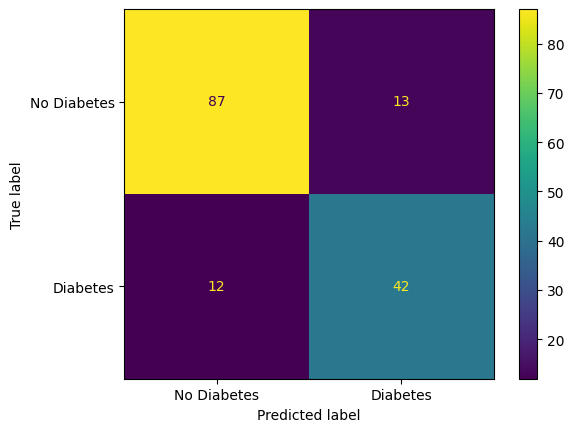

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.8116883116883117

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       100
           1       0.75      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

[[87 13]
 [16 38]]


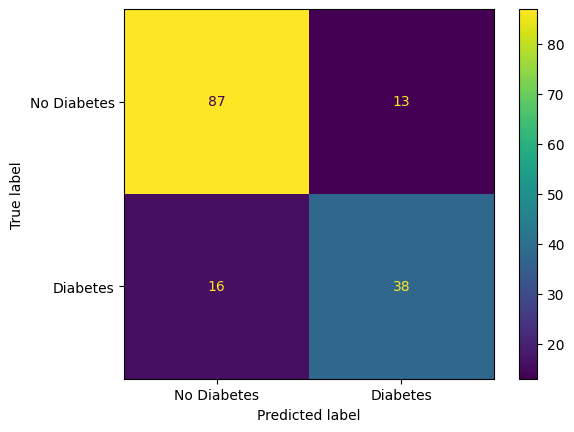

           Model  Training Accuracy  Testing Accuracy
0            SVM           0.895765          0.837662
1  Decision Tree           1.000000          0.811688


In [11]:
columns_with_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns_with_missing] = df[columns_with_missing].replace(0, np.nan)


X = df.drop('Outcome', axis=1)

y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


preprocessing = Pipeline([

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])


svm_model = Pipeline([

    ('preprocessing', preprocessing),

    ('classifier', SVC(kernel='rbf'))

])


svm_model.fit(X_train, y_train)


svm_train_pred = svm_model.predict(X_train)

svm_test_pred = svm_model.predict(X_test)


svm_train_accuracy = accuracy_score(y_train, svm_train_pred)

svm_test_accuracy = accuracy_score(y_test, svm_test_pred)

print("SVM Training Accuracy:", svm_train_accuracy)

print("SVM Testing Accuracy:", svm_test_accuracy)

print("\nSVM Classification Report:")

print(classification_report(y_test, svm_test_pred))

cm = confusion_matrix(y_test, svm_test_pred)

print(cm)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No Diabetes", "Diabetes"]

)

disp.plot()

plt.show()


dt_model = Pipeline([

    ('preprocessing', preprocessing),

    ('classifier', DecisionTreeClassifier(random_state=42))

])


dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)

dt_test_pred = dt_model.predict(X_test)


dt_train_accuracy = accuracy_score(y_train, dt_train_pred)

dt_test_accuracy = accuracy_score(y_test, dt_test_pred)

print("Decision Tree Training Accuracy:", dt_train_accuracy)

print("Decision Tree Testing Accuracy:", dt_test_accuracy)

print("\nDecision Tree Classification Report:")

print(classification_report(y_test, dt_test_pred))

cm = confusion_matrix(y_test, dt_test_pred)

print(cm)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No Diabetes", "Diabetes"]

)

disp.plot()

plt.show()


comparison = pd.DataFrame({

    'Model': ['SVM', 'Decision Tree'],

    'Training Accuracy': [

        svm_train_accuracy,

        dt_train_accuracy

    ],

    'Testing Accuracy': [

        svm_test_accuracy,

        dt_test_accuracy

    ]

})

print(comparison)

## Model Comparison

after analyzing both model SVM is better than DT because DT cause overfitting and SVM accuracy is well generalized
